This code will

1. Sample `N` vehicles per the SCT (Mexico specific) class distribution; for each, it will simulate the midspan stress history, run rainflow cycle counting, accumulate cycles.
2. Compute `D_base` (yearly Miner damage) for both Eurocode and AASHTO S-N (this varies due to different SN fatigue curve definitions)
3. Calibration sweep: solve for `x_F` using reliability indices of 1 and 3.
4. Sensitivity sweep: fix `x_F`, vary the growth rate, plot reliability index.

`N` is set to `TDPA / 2 · 365` . In brief, TDPA is daily average transit. Its divided by two because its bidirectional and here we analyze only one girder of a two-girder bridge. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
import import_ipynb

from sample_vehicle import sample_vehicle, vehicle_catalog
from simulate_midspan_moment import simulate_midspan_moment
from moment_to_stress import moment_to_stress
from rainflow import rainflow_cycles, rainflow_to_arrays
from sn_curve import cycles_to_failure, category_to_kgf_per_m2
from miner_damage import miner_damage_from_cycles
from monte_carlo_failure import monte_carlo_failure, Pf_to_beta, beta_to_Pf
from traffic_growth_calibration import (
    compute_d_grown,
    calibration_sweep,
    sensitivity_sweep,
    plot_calibration,
)

# parameters
TDPA_BIDIRECTIONAL = 5544                       # SCT 2024 is 6362, both directions. 5544 is 1995, year of construction.
TDPA_ONE_DIRECTION = TDPA_BIDIRECTIONAL // 2    # one girder = one direction
N = TDPA_ONE_DIRECTION * 365                    # vehicles simulated per year

l = 76.5                                        # m
dr = 50                                         # m
steps_per_meter = 1

I = 0.10859586082379513                         # m^4
y = 1                                           # m, distance to extreme fiber
A = 0.16376904                                  # m^2

# Two-girder bridge (Meneses Rojas 2026, p. 63): each girder carries half
# of the deck weight + its own self-weight
w_deadload = 7800 * A + 2250                     # kgf/m per girder
M_DL = w_deadload * l**2 / 8                    # kgf·m
sigma_DL = M_DL * y / I                         # kgf/m^2

mu = 0.71
axial_mode = "after_midspan"

# as found in empirical data
class_probs = {"M":0.9, "A":69.2, "B":6.4, "C2":4.9, "C3":6.4,
               "T3S2":5.9, "T3S3":1.7, "T3S2R4":3.7, "Otros":0.9}


# material and detail category
SIGMA_U_MPa  = 460.0                            # ASTM A572 Gr. 60
sigma_u      = category_to_kgf_per_m2(SIGMA_U_MPa)
DETAIL_CAT_MPa = 100.0                          # EN 1993-1-9 Cat 100
delta_sigma_C = category_to_kgf_per_m2(DETAIL_CAT_MPa)

# calibration parameters
T_design        = 75
alpha_traffic   = 0.025
beta_targets    = [1.0, 3.0]
N_MC            = 500000

print(f"TDPA bidirectional       : {TDPA_BIDIRECTIONAL}")
print(f"TDPA one direction       : {TDPA_ONE_DIRECTION}")
print(f"N vehicles simulated/yr  : {N:,}")
print(f"σ_DL                     : {sigma_DL*9.80665e-6:.1f} MPa")
print(f"Detail category Δσ_C     : {DETAIL_CAT_MPa:.0f} MPa")
print(f"T_design / α_traffic     : {T_design} yr / {alpha_traffic*100:.1f}%/yr")


TDPA bidirectional       : 5544
TDPA one direction       : 2772
N vehicles simulated/yr  : 1,011,780
σ_DL                     : 233.0 MPa
Detail category Δσ_C     : 100 MPa
T_design / α_traffic     : 75 yr / 2.5%/yr


In [3]:
all_ranges = []
all_means  = []
all_counts = []

for k in range(N):
    # get a random vehicle
    veh = sample_vehicle(class_probs)
    Pi = veh["Pi"]
    di = veh["di"]

    # essentially ignore lighter vehicles
    if Pi.sum() < 200.0:
        continue

    # calculate midspan moment
    pos_last, M_mid, axle_pos_time = simulate_midspan_moment(
        Pi, di, l=l, dr=dr, steps_per_meter=steps_per_meter
    )

    # stress
    sigma_total, sigma_b, sigma_axial = moment_to_stress(
        M_mid=0.7*M_mid,
        axle_pos_time=axle_pos_time,
        Pi_full=Pi,
        pos_last=pos_last,
        l=l, I=I, y=y, A=A,
        mu=mu, axial_mode=axial_mode, to_pa=False,
    )

    # rainflow counting
    cycles = rainflow_cycles(sigma_total)
    if not cycles:
        continue
    r, m, c = rainflow_to_arrays(cycles)
    all_ranges.append(r)
    all_means.append(m + sigma_DL)              # add dead-load mean stress
    all_counts.append(c)

    # progress bar
    percent_complete = (k + 1) / N * 100
    if (k + 1) % max(1, N // 100) == 0 or k == N - 1:
        print(f"Progress: {percent_complete:5.1f}%  ({k+1:>7,} / {N:,})")

stress_ranges = np.concatenate(all_ranges)
stress_means  = np.concatenate(all_means)
stress_counts = np.concatenate(all_counts)

print(f"\nDone. Total cycles: {stress_counts.sum():,.0f}")


Progress:   1.0%  ( 10,117 / 1,011,780)
Progress:   2.0%  ( 20,234 / 1,011,780)
Progress:   3.0%  ( 30,351 / 1,011,780)
Progress:   4.0%  ( 40,468 / 1,011,780)
Progress:   5.0%  ( 50,585 / 1,011,780)
Progress:   6.0%  ( 60,702 / 1,011,780)
Progress:   7.0%  ( 70,819 / 1,011,780)
Progress:   8.0%  ( 80,936 / 1,011,780)
Progress:   9.0%  ( 91,053 / 1,011,780)
Progress:  10.0%  (101,170 / 1,011,780)
Progress:  11.0%  (111,287 / 1,011,780)
Progress:  12.0%  (121,404 / 1,011,780)
Progress:  13.0%  (131,521 / 1,011,780)
Progress:  14.0%  (141,638 / 1,011,780)
Progress:  15.0%  (151,755 / 1,011,780)
Progress:  16.0%  (161,872 / 1,011,780)
Progress:  17.0%  (171,989 / 1,011,780)
Progress:  18.0%  (182,106 / 1,011,780)
Progress:  19.0%  (192,223 / 1,011,780)
Progress:  20.0%  (202,340 / 1,011,780)
Progress:  21.0%  (212,457 / 1,011,780)
Progress:  22.0%  (222,574 / 1,011,780)
Progress:  23.0%  (232,691 / 1,011,780)
Progress:  24.0%  (242,808 / 1,011,780)
Progress:  25.0%  (252,925 / 1,011,780)


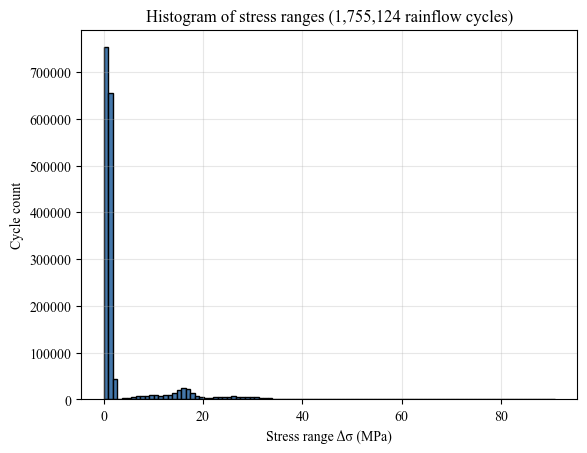

max:     90.80 MPa
mean:     5.78 MPa
p95:     28.40 MPa
p99:     59.48 MPa
Δσ_eq (m=3, damage weighted) is 17.65 MPa


In [4]:
#histogram
stress_ranges_MPa = stress_ranges * 9.80665e-6

bins = np.linspace(0, stress_ranges_MPa.max(), 100)
plt.hist(stress_ranges_MPa, bins=bins, weights=stress_counts,
         edgecolor='black', color="#4477AA")
plt.xlabel("Stress range Δσ (MPa)")
plt.ylabel("Cycle count")
plt.title(f"Histogram of stress ranges ({stress_counts.sum():,.0f} rainflow cycles)")
plt.grid(True, alpha=0.3)
plt.show()

print(f"max:    {stress_ranges_MPa.max():6.2f} MPa")
print(f"mean:   {stress_ranges_MPa.mean():6.2f} MPa")
print(f"p95:    {np.percentile(stress_ranges_MPa, 95):6.2f} MPa")
print(f"p99:    {np.percentile(stress_ranges_MPa, 99):6.2f} MPa")
print(f"Δσ_eq (m=3, damage weighted) is "
      f"{(np.average(stress_ranges_MPa**3, weights=stress_counts))**(1/3):.2f} MPa")


In [5]:
# miner damage
D_eurocode, details_ec = miner_damage_from_cycles(
    ranges=stress_ranges,
    means=stress_means,
    counts=stress_counts,
    delta_sigma_C=delta_sigma_C,
    sigma_u=sigma_u,
    sn_model="eurocode",
    apply_goodman=False,
)

D_aashto, details_a = miner_damage_from_cycles(
    ranges=stress_ranges,
    means=stress_means,
    counts=stress_counts,
    delta_sigma_C=delta_sigma_C,
    sigma_u=sigma_u,
    sn_model="aashto",
    apply_goodman=False,
)

print(f"D_base (Eurocode bilinear) : {D_eurocode:.2e} per year")
print(f"D_base (AASHTO single)     : {D_aashto:.2e} per year")
print(f"Years to D = 1 (Eurocode)  : {1/D_eurocode:.1f}")
print(f"Years to D = 1 (AASHTO)    : {1/D_aashto:.1f}")


#print(f"D_ec / D_a ratio:   {D_eurocode/D_aashto:.2f} x")


D_base (Eurocode bilinear) : 2.42e-03 per year
D_base (AASHTO single)     : 9.76e-05 per year
Years to D = 1 (Eurocode)  : 412.9
Years to D = 1 (AASHTO)    : 10247.9


  β_target = 1.0   would require  x_F = 1.3058
  β_target = 3.0   would require  x_F = 0.6815
  β_target = 1.0   would require  x_F = 4.0000
  β_target = 3.0   would require  x_F = 4.0000

Calibration summary (central α = 2.5%/yr, T = 75 yr):
  β_target     x_F (Eurocode)       x_F (AASHTO)
------------------------------------------------
       1.0              1.306                  4
       3.0              0.681                  4


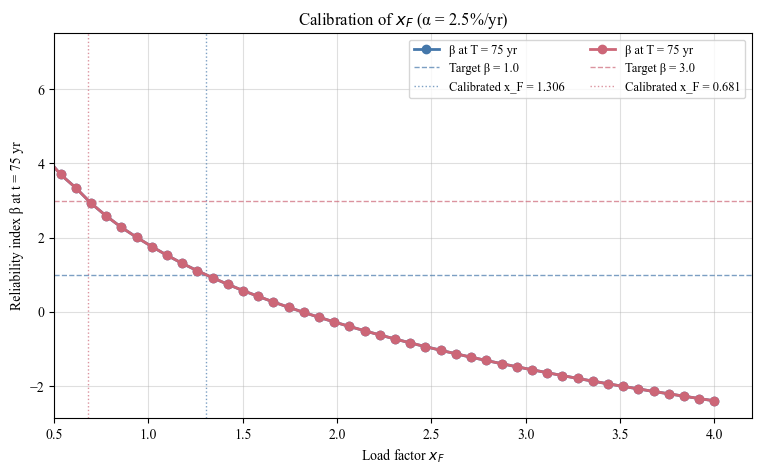

In [6]:
# calibration sweep
calibrated_ec, sweep_ec = calibration_sweep(
    D_base=D_eurocode,
    alpha_traffic=alpha_traffic,
    beta_targets=beta_targets,
    T_design=T_design,
    N_samples=N_MC,
    seed=42,
)

calibrated_a, sweep_a = calibration_sweep(
    D_base=D_aashto,
    alpha_traffic=alpha_traffic,
    beta_targets=beta_targets,
    T_design=T_design,
    N_samples=N_MC,
    seed=42,
)

print(f"\nCalibration summary (central α = {alpha_traffic*100:.1f}%/yr, T = {T_design} yr):")
print(f"{'β_target':>10} {'x_F (Eurocode)':>18} {'x_F (AASHTO)':>18}")
print("-" * 48)
for bt in beta_targets:
    print(f"{bt:>10.1f} {calibrated_ec[bt]:>18.3f} {calibrated_a[bt]:>18.0f}")

# Calibration plot 
plot_calibration(calibrated_ec, sweep_ec,
                 T_design=T_design, alpha_traffic=alpha_traffic)
plt.show()


Sensitivity at x_F = 1.3058  (Eurocode, β=1.0 calibrated)



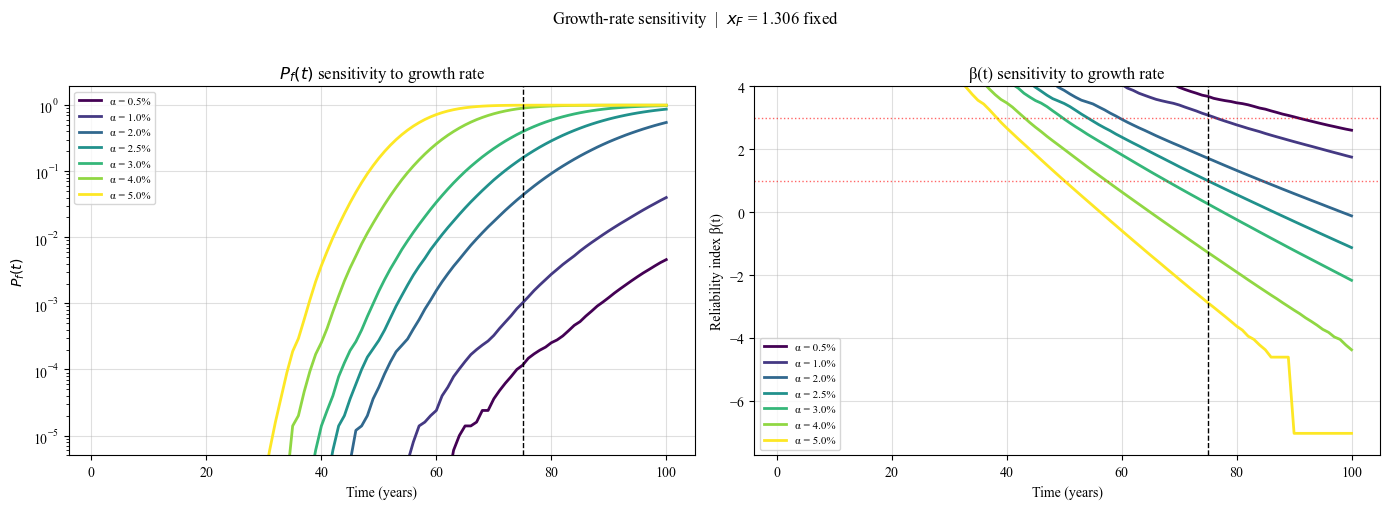


  α (%/yr)      β at T
------------------------
       0.5       3.681
       1.0       3.086
       2.0       1.714
       2.5       0.997
       3.0       0.264
       4.0      -1.281
       5.0      -2.881


In [7]:
# sensitivity sweep
x_F_central = calibrated_ec[1.0]
print(f"Sensitivity at x_F = {x_F_central:.4f}  "
      f"(Eurocode, β=1.0 calibrated)\n")

curves = sensitivity_sweep(
    D_base=D_eurocode,
    x_F=x_F_central,
    T_design=T_design,
    N_samples=N_MC,
    seed=42,
)

print(f"\n{'α (%/yr)':>10}  {'β at T':>10}")
print("-" * 24)
for alpha in sorted(curves.keys()):
    beta_T = float(np.interp(T_design, curves[alpha]["years"], curves[alpha]["beta"]))
    print(f"{alpha*100:>10.1f}  {beta_T:>10.3f}")



In [8]:
# data summary
print("=" * 65)
print("  Fatigue load factor calibration summary")
print("=" * 65)
print(f"  Bridge span L                : {l} m")
print(f"  TDPA (one direction)         : {TDPA_ONE_DIRECTION:} veh/day")
print(f"  Vehicles simulated           : {N:,}")
print(f"  Total rainflow cycles        : {stress_counts.sum():,.0f}")
print(f"  Detail category              : EN 1993-1-9 Cat {DETAIL_CAT_MPa:.0f} MPa")
print(f"  σ_DL (per girder)            : {sigma_DL*9.80665e-6:.1f} MPa")
print(f"  Δσ_eq (damage-weighted, m=3) : "
      f"{(np.average(stress_ranges_MPa**3, weights=stress_counts))**(1/3):.2f} MPa")
print("-" * 65)
print(f"  D_base (Eurocode)            : {D_eurocode:.4e} / yr")
print(f"  D_base (AASHTO)              : {D_aashto:.4e} / yr")
print(f"  Years to D = 1 (Eurocode)    : {1/D_eurocode:7.1f}")
print(f"  Years to D = 1 (AASHTO)      : {1/D_aashto:7.1f}")
print("-" * 65)
print(f"  Central scenario : T = {T_design} yr,  α = {alpha_traffic*100:.1f}%/yr")
print(f"  Calibrated x_F  (Eurocode)   :  β=1.0 -> {calibrated_ec[1.0]:.3f}   "
      f"β=3.0 -> {calibrated_ec[3.0]:.3f}")
print(f"  Calibrated x_F  (AASHTO)     :  β=1.0 -> {calibrated_a[1.0]:.3f}   "
      f"β=3.0 -> {calibrated_a[3.0]:.3f}")
print("=" * 65)


  Fatigue load factor calibration summary
  Bridge span L                : 76.5 m
  TDPA (one direction)         : 2772 veh/day
  Vehicles simulated           : 1,011,780
  Total rainflow cycles        : 1,755,124
  Detail category              : EN 1993-1-9 Cat 100 MPa
  σ_DL (per girder)            : 233.0 MPa
  Δσ_eq (damage-weighted, m=3) : 17.65 MPa
-----------------------------------------------------------------
  D_base (Eurocode)            : 2.4221e-03 / yr
  D_base (AASHTO)              : 9.7581e-05 / yr
  Years to D = 1 (Eurocode)    :   412.9
  Years to D = 1 (AASHTO)      : 10247.9
-----------------------------------------------------------------
  Central scenario : T = 75 yr,  α = 2.5%/yr
  Calibrated x_F  (Eurocode)   :  β=1.0 -> 1.306   β=3.0 -> 0.681
  Calibrated x_F  (AASHTO)     :  β=1.0 -> 4.000   β=3.0 -> 4.000
